In [12]:
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
import os

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from imblearn.over_sampling import SMOTE

# Make sure output folders exist
os.makedirs('../models', exist_ok=True)
os.makedirs('../data/processed', exist_ok=True)
os.makedirs('../figures', exist_ok=True)

In [13]:
print("Loading with memory-optimized dtypes...")

# Read column names first without loading data
cols = pd.read_csv('../data/processed/cleaned_data.csv', nrows=0).columns.tolist()
feature_cols = [c for c in cols if c != 'Label']

# Load with float32 for all features — halves memory vs float64
dtype_map = {col: 'float32' for col in feature_cols}

df = pd.read_csv(
    '../data/processed/cleaned_data.csv',
    dtype=dtype_map   # Label column auto-loads as string, everything else float32
)

print(f"Shape:   {df.shape}")
print(f"Memory usage: {df.memory_usage(deep=True).sum() / 1e9:.2f} GB")
print(f"Label unique values: {df['Label'].nunique()}")
print(df['Label'].value_counts())

Loading with memory-optimized dtypes...
Shape:   (2519404, 79)
Memory usage: 0.93 GB
Label unique values: 15
Label
BENIGN                        2094360
DoS Hulk                       172717
DDoS                           128011
PortScan                        90130
DoS GoldenEye                   10286
FTP-Patator                      5931
DoS slowloris                    5384
DoS Slowhttptest                 5228
SSH-Patator                      3219
Bot                              1948
Web Attack � Brute Force         1470
Web Attack � XSS                  652
Infiltration                       36
Web Attack � Sql Injection         21
Heartbleed                         11
Name: count, dtype: int64


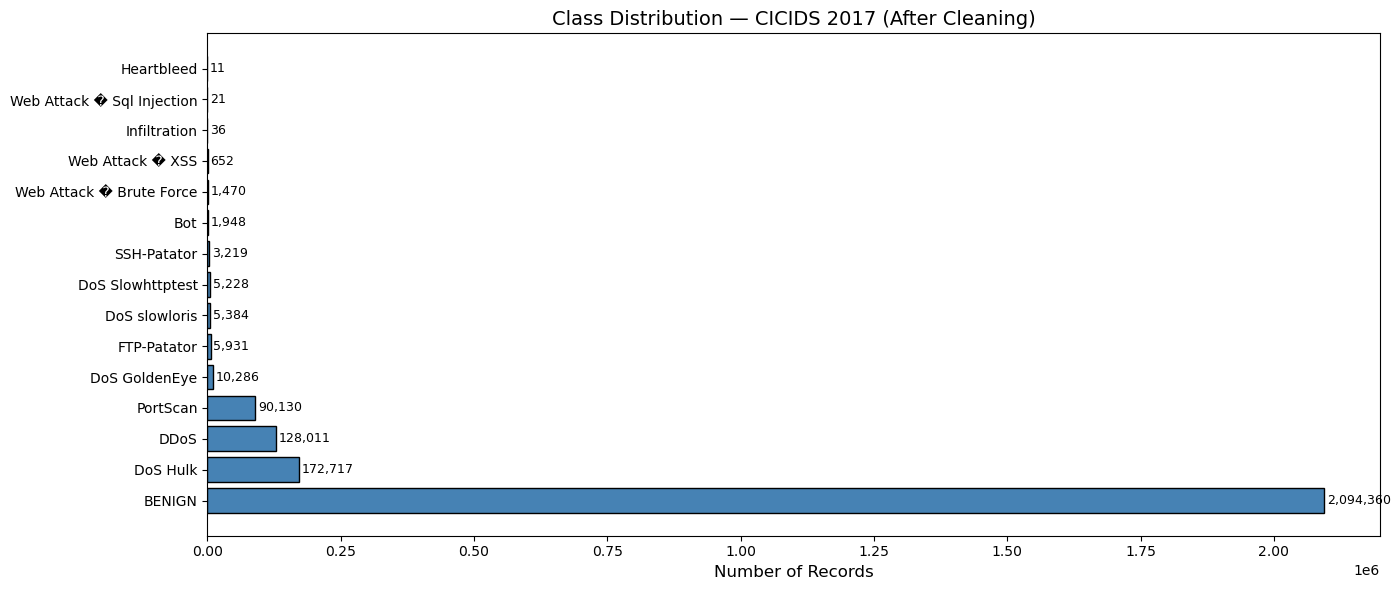

Saved: figures/class_distribution.png


In [14]:
label_counts = df['Label'].value_counts()

plt.figure(figsize=(14, 6))
bars = plt.barh(label_counts.index, label_counts.values, color='steelblue', edgecolor='black')
plt.xlabel('Number of Records', fontsize=12)
plt.title('Class Distribution — CICIDS 2017 (After Cleaning)', fontsize=14)
plt.tight_layout()

# Annotate bars with count
for bar, val in zip(bars, label_counts.values):
    plt.text(bar.get_width() + 5000, bar.get_y() + bar.get_height()/2,
             f'{val:,}', va='center', fontsize=9)

plt.savefig('../figures/class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: figures/class_distribution.png")

In [15]:
X = df.drop('Label', axis=1)
y_raw = df['Label']

print(f"Feature matrix shape: {X.shape}")
print(f"Label series shape: {y_raw.shape}")
print(f"Feature columns: {list(X.columns)}")

Feature matrix shape: (2519404, 78)
Label series shape: (2519404,)
Feature columns: ['Destination Port', 'Flow Duration', 'Total Fwd Packets', 'Total Backward Packets', 'Total Length of Fwd Packets', 'Total Length of Bwd Packets', 'Fwd Packet Length Max', 'Fwd Packet Length Min', 'Fwd Packet Length Mean', 'Fwd Packet Length Std', 'Bwd Packet Length Max', 'Bwd Packet Length Min', 'Bwd Packet Length Mean', 'Bwd Packet Length Std', 'Flow Bytes/s', 'Flow Packets/s', 'Flow IAT Mean', 'Flow IAT Std', 'Flow IAT Max', 'Flow IAT Min', 'Fwd IAT Total', 'Fwd IAT Mean', 'Fwd IAT Std', 'Fwd IAT Max', 'Fwd IAT Min', 'Bwd IAT Total', 'Bwd IAT Mean', 'Bwd IAT Std', 'Bwd IAT Max', 'Bwd IAT Min', 'Fwd PSH Flags', 'Bwd PSH Flags', 'Fwd URG Flags', 'Bwd URG Flags', 'Fwd Header Length', 'Bwd Header Length', 'Fwd Packets/s', 'Bwd Packets/s', 'Min Packet Length', 'Max Packet Length', 'Packet Length Mean', 'Packet Length Std', 'Packet Length Variance', 'FIN Flag Count', 'SYN Flag Count', 'RST Flag Count', 'PS

In [16]:
le = LabelEncoder()
y = le.fit_transform(y_raw)

print("Label encoding mapping:")
for i, cls in enumerate(le.classes_):
    count = (y == i).sum()
    print(f"  {i:2d} → {cls:<45} ({count:>7,} records)")

# Save immediately — app.py needs this
joblib.dump(le, '../models/label_encoder.pkl')
print("\n✅ Saved: models/label_encoder.pkl")

Label encoding mapping:
   0 → BENIGN                                        (2,094,360 records)
   1 → Bot                                           (  1,948 records)
   2 → DDoS                                          (128,011 records)
   3 → DoS GoldenEye                                 ( 10,286 records)
   4 → DoS Hulk                                      (172,717 records)
   5 → DoS Slowhttptest                              (  5,228 records)
   6 → DoS slowloris                                 (  5,384 records)
   7 → FTP-Patator                                   (  5,931 records)
   8 → Heartbleed                                    (     11 records)
   9 → Infiltration                                  (     36 records)
  10 → PortScan                                      ( 90,130 records)
  11 → SSH-Patator                                   (  3,219 records)
  12 → Web Attack � Brute Force                      (  1,470 records)
  13 → Web Attack � Sql Injection                  

In [17]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X).astype(np.float32)  # Ensure output is float32 to save memory

print(f"Scaled matrix shape: {X_scaled.shape}")
print(f"Mean of first feature (should be ~0): {X_scaled[:, 0].mean():.4f}")
print(f"Std of first feature (should be ~1):  {X_scaled[:, 0].std():.4f}")

# Save scaler — app.py needs this to scale incoming data
joblib.dump(scaler, '../models/scaler.pkl')
print("✅ Saved: models/scaler.pkl")

Scaled matrix shape: (2519404, 78)
Mean of first feature (should be ~0): -0.0000
Std of first feature (should be ~1):  1.0000
✅ Saved: models/scaler.pkl


In [18]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y,
    test_size=0.2,
    random_state=42,
    stratify=y        # CRITICAL: ensures each class is proportionally represented
)
del X_scaled, X, df
import gc
gc.collect()

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape:  {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape:  {y_test.shape}")

print(f"\nTrain class distribution:")
unique, counts = np.unique(y_train, return_counts=True)
for u, c in zip(unique, counts):
    print(f"  {le.classes_[u]:<45} {c:>7,}")

X_train shape: (2015523, 78)
X_test shape:  (503881, 78)
y_train shape: (2015523,)
y_test shape:  (503881,)

Train class distribution:
  BENIGN                                        1,675,488
  Bot                                             1,558
  DDoS                                          102,409
  DoS GoldenEye                                   8,229
  DoS Hulk                                      138,173
  DoS Slowhttptest                                4,182
  DoS slowloris                                   4,307
  FTP-Patator                                     4,745
  Heartbleed                                          9
  Infiltration                                       29
  PortScan                                       72,104
  SSH-Patator                                     2,575
  Web Attack � Brute Force                        1,176
  Web Attack � Sql Injection                         17
  Web Attack � XSS                                  522


In [19]:
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from imblearn.pipeline import Pipeline

print("Class counts before balancing:")
unique, counts = np.unique(y_train, return_counts=True)
for u, c in zip(unique, counts):
    print(f"  {le.classes_[u]:<45} {c:>7,}")

# Step 1: Define sampling strategies
# Undersample: cap any class above 80,000 down to 80,000
# Oversample:  bring any class below 2,000 up to 2,000

under_strategy = {}
over_strategy  = {}

CAP    = 80000   # max samples per class after undersampling
FLOOR  = 2000    # min samples per class after oversampling

unique_classes, class_counts = np.unique(y_train, return_counts=True)

for cls, cnt in zip(unique_classes, class_counts):
    if cnt > CAP:
        under_strategy[cls] = CAP

for cls, cnt in zip(unique_classes, class_counts):
    effective_count = under_strategy.get(cls, cnt)
    if effective_count < FLOOR:
        over_strategy[cls] = FLOOR

print(f"\nUndersampling {len(under_strategy)} classes down to {CAP:,}")
print(f"Oversampling  {len(over_strategy)} classes up to {FLOOR:,}")

# Step 2: Undersample first
rus = RandomUnderSampler(sampling_strategy=under_strategy, random_state=42)
X_under, y_under = rus.fit_resample(X_train, y_train)

print(f"\nAfter undersampling: {X_under.shape}")

# Step 3: SMOTE on the now-smaller dataset
smote = SMOTE(sampling_strategy=over_strategy, random_state=42)
X_train_bal, y_train_bal = smote.fit_resample(X_under, y_under)

print(f"After SMOTE:         {X_train_bal.shape}")

print("\nFinal class distribution:")
unique, counts = np.unique(y_train_bal, return_counts=True)
for u, c in zip(unique, counts):
    print(f"  {le.classes_[u]:<45} {c:>7,}")

Class counts before balancing:
  BENIGN                                        1,675,488
  Bot                                             1,558
  DDoS                                          102,409
  DoS GoldenEye                                   8,229
  DoS Hulk                                      138,173
  DoS Slowhttptest                                4,182
  DoS slowloris                                   4,307
  FTP-Patator                                     4,745
  Heartbleed                                          9
  Infiltration                                       29
  PortScan                                       72,104
  SSH-Patator                                     2,575
  Web Attack � Brute Force                        1,176
  Web Attack � Sql Injection                         17
  Web Attack � XSS                                  522

Undersampling 3 classes down to 80,000
Oversampling  6 classes up to 2,000

After undersampling: (339453, 78)
After SMOTE:    

In [21]:
print("Running quick Random Forest for feature importance...")

feat_selector = RandomForestClassifier(
    n_estimators=50,
    max_depth=10,
    random_state=42,
    n_jobs=-1
)
feat_selector.fit(X_train_bal, y_train_bal)

importances = feat_selector.feature_importances_

# Get feature names without reloading the full dataset
cols = pd.read_csv('../data/processed/cleaned_data.csv', nrows=0).columns.tolist()
feature_names_all = [c for c in cols if c != 'Label']

indices = np.argsort(importances)[::-1]

print("\nTop 25 features by importance:")
for rank, idx in enumerate(indices[:25]):
    print(f"  {rank+1:2d}. {feature_names_all[idx]:<45} {importances[idx]:.4f}")

Running quick Random Forest for feature importance...

Top 25 features by importance:
   1. Flow IAT Max                                  0.0545
   2. Fwd Packet Length Mean                        0.0520
   3. Avg Fwd Segment Size                          0.0494
   4. Fwd Packet Length Max                         0.0441
   5. Subflow Fwd Bytes                             0.0421
   6. Bwd Packets/s                                 0.0407
   7. Init_Win_bytes_backward                       0.0360
   8. Total Length of Fwd Packets                   0.0359
   9. Flow Duration                                 0.0323
  10. Flow Packets/s                                0.0311
  11. Fwd IAT Max                                   0.0248
  12. Fwd IAT Total                                 0.0224
  13. Average Packet Size                           0.0223
  14. Fwd IAT Mean                                  0.0209
  15. Init_Win_bytes_forward                        0.0199
  16. Bwd Packet Length Max  

In [22]:
TOP_N = 25
top_indices = indices[:TOP_N]
top_feature_names = [feature_names_all[i] for i in top_indices]

# Slice both train and test down to top 25
X_train_final = X_train_bal[:, top_indices]
X_test_final  = X_test[:, top_indices]

print(f"X_train_final shape: {X_train_final.shape}")
print(f"X_test_final shape:  {X_test_final.shape}")

# Save everything
joblib.dump(X_train_final,    '../data/processed/X_train.pkl')
joblib.dump(X_test_final,     '../data/processed/X_test.pkl')
joblib.dump(y_train_bal,      '../data/processed/y_train.pkl')
joblib.dump(y_test,           '../data/processed/y_test.pkl')
joblib.dump(top_feature_names,'../models/feature_names.pkl')
joblib.dump(top_indices,      '../models/feature_indices.pkl')

print("\n✅ All Phase 2 files saved:")
print("   data/processed/X_train.pkl")
print("   data/processed/X_test.pkl")
print("   data/processed/y_train.pkl")
print("   data/processed/y_test.pkl")
print("   models/feature_names.pkl")
print("   models/feature_indices.pkl")
print("   models/label_encoder.pkl")
print("   models/scaler.pkl")

X_train_final shape: (348142, 25)
X_test_final shape:  (503881, 25)

✅ All Phase 2 files saved:
   data/processed/X_train.pkl
   data/processed/X_test.pkl
   data/processed/y_train.pkl
   data/processed/y_test.pkl
   models/feature_names.pkl
   models/feature_indices.pkl
   models/label_encoder.pkl
   models/scaler.pkl


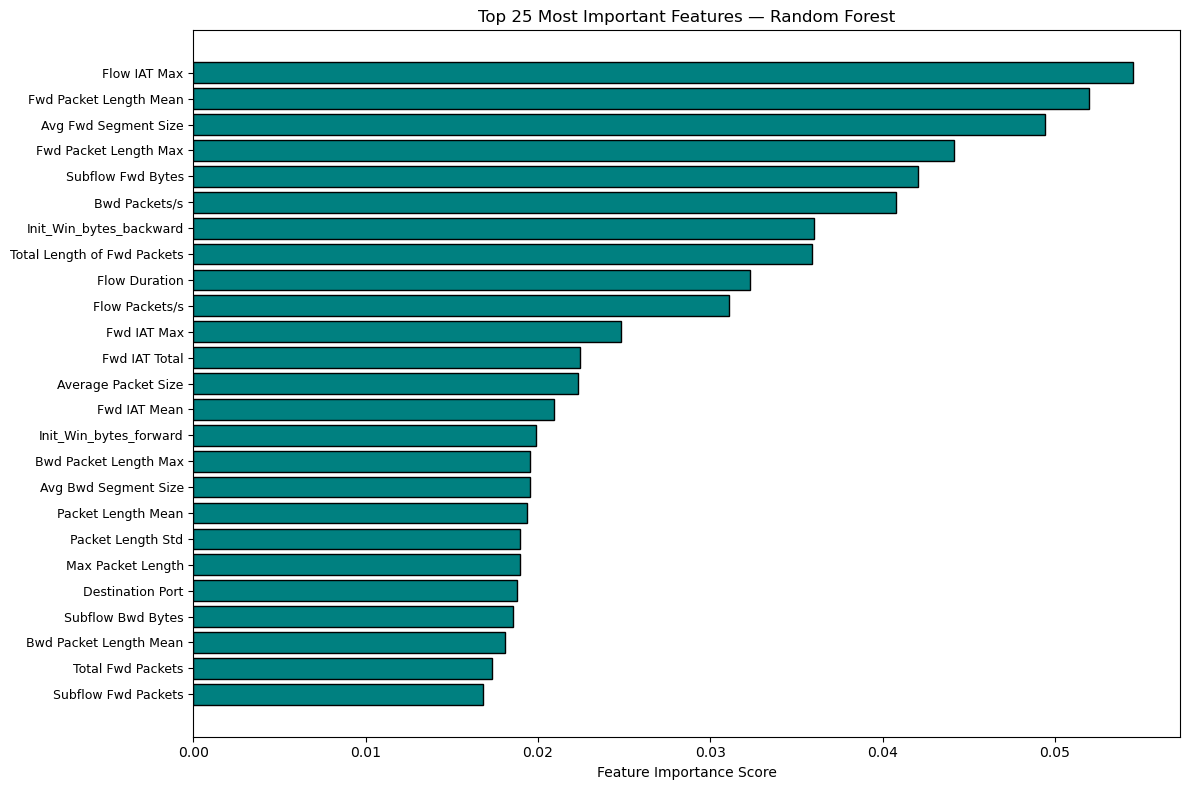

Saved: figures/feature_importance.png


In [23]:
plt.figure(figsize=(12, 8))
plt.barh(
    range(TOP_N),
    importances[top_indices],
    color='teal', edgecolor='black'
)
plt.yticks(range(TOP_N), top_feature_names, fontsize=9)
plt.xlabel('Feature Importance Score')
plt.title('Top 25 Most Important Features — Random Forest')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('../figures/feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: figures/feature_importance.png")

In [24]:
print("="*50)
print("PHASE 2 COMPLETE — FINAL VERIFICATION")
print("="*50)

X_tr = joblib.load('../data/processed/X_train.pkl')
X_te = joblib.load('../data/processed/X_test.pkl')
y_tr = joblib.load('../data/processed/y_train.pkl')
y_te = joblib.load('../data/processed/y_test.pkl')
fn   = joblib.load('../models/feature_names.pkl')
le2  = joblib.load('../models/label_encoder.pkl')

print(f"X_train: {X_tr.shape}")
print(f"X_test:  {X_te.shape}")
print(f"y_train: {y_tr.shape}")
print(f"y_test:  {y_te.shape}")
print(f"Features: {fn}")
print(f"Classes:  {list(le2.classes_)}")
print("\n✅ All good. Ready for Phase 3.")

PHASE 2 COMPLETE — FINAL VERIFICATION
X_train: (348142, 25)
X_test:  (503881, 25)
y_train: (348142,)
y_test:  (503881,)
Features: ['Flow IAT Max', 'Fwd Packet Length Mean', 'Avg Fwd Segment Size', 'Fwd Packet Length Max', 'Subflow Fwd Bytes', 'Bwd Packets/s', 'Init_Win_bytes_backward', 'Total Length of Fwd Packets', 'Flow Duration', 'Flow Packets/s', 'Fwd IAT Max', 'Fwd IAT Total', 'Average Packet Size', 'Fwd IAT Mean', 'Init_Win_bytes_forward', 'Bwd Packet Length Max', 'Avg Bwd Segment Size', 'Packet Length Mean', 'Packet Length Std', 'Max Packet Length', 'Destination Port', 'Subflow Bwd Bytes', 'Bwd Packet Length Mean', 'Total Fwd Packets', 'Subflow Fwd Packets']
Classes:  ['BENIGN', 'Bot', 'DDoS', 'DoS GoldenEye', 'DoS Hulk', 'DoS Slowhttptest', 'DoS slowloris', 'FTP-Patator', 'Heartbleed', 'Infiltration', 'PortScan', 'SSH-Patator', 'Web Attack � Brute Force', 'Web Attack � Sql Injection', 'Web Attack � XSS']

✅ All good. Ready for Phase 3.
